In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Expanded_data_with_more_features.csv")
df.sort_values(by=['MathScore', 'ReadingScore', 'WritingScore'], ascending=False)

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
432,458,female,group E,bachelor's degree,standard,none,married,regularly,NaN,2.0,school_bus,NaN,100,100,100
868,916,male,group E,bachelor's degree,standard,completed,single,regularly,yes,7.0,private,5 - 10,100,100,100
912,962,female,group E,associate's degree,standard,none,single,regularly,no,3.0,school_bus,5 - 10,100,100,100
981,34,female,group E,high school,standard,completed,divorced,regularly,yes,1.0,private,5 - 10,100,100,100
989,43,female,group E,bachelor's degree,standard,completed,married,sometimes,yes,0.0,private,5 - 10,100,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20860,199,female,group D,some college,free/reduced,none,married,regularly,NaN,1.0,school_bus,< 5,9,26,27
12789,572,female,group A,some college,free/reduced,none,married,sometimes,yes,0.0,school_bus,5 - 10,9,23,20
928,980,female,group B,high school,free/reduced,none,married,sometimes,yes,1.0,private,5 - 10,8,24,23
14494,375,male,group D,high school,free/reduced,none,divorced,sometimes,yes,2.0,school_bus,< 5,7,11,12


In [21]:
Q1 = df['MathScore'].quantile(0.25)
Q2 = df['MathScore'].quantile(0.75)
IQR = Q2 - Q1
lower = Q1 - 1.5 * IQR
upper = Q1 + 1.5 * IQR

sorted_df = df[(df['MathScore'] >= lower) & (df['MathScore'] <= upper)].sort_values('MathScore')
sorted_df

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
8373,863,male,group C,some high school,free/reduced,none,NaN,sometimes,yes,3.0,school_bus,< 5,23,24,16
27861,726,female,group D,high school,free/reduced,completed,NaN,regularly,no,2.0,school_bus,NaN,23,35,43
19180,404,female,group B,high school,free/reduced,none,married,sometimes,yes,2.0,school_bus,5 - 10,23,33,34
15740,719,female,group A,associate's degree,free/reduced,none,married,never,yes,5.0,school_bus,> 10,23,36,37
16485,529,female,group B,some college,free/reduced,NaN,married,regularly,no,3.0,school_bus,< 5,23,52,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13161,963,male,group C,bachelor's degree,standard,completed,married,regularly,no,3.0,private,> 10,89,76,84
13162,964,female,group C,some high school,standard,completed,divorced,regularly,yes,4.0,private,5 - 10,89,99,100
21888,311,female,group D,master's degree,standard,NaN,married,never,yes,1.0,NaN,5 - 10,89,97,100
28617,531,male,group D,high school,standard,none,married,sometimes,no,1.0,private,< 5,89,83,81


In [24]:
q_01 = np.quantile(df['MathScore'], .01)
q_99 = np.quantile(df['MathScore'], .99)

sorted_data = df[(df['MathScore'] >= q_01) & (df['MathScore'] <= q_99)].sort_values('MathScore')
sorted_data

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
11343,23,female,group C,associate's degree,standard,none,married,regularly,no,1.0,private,5 - 10,30,46,46
30435,779,female,group B,some college,free/reduced,completed,NaN,never,no,1.0,NaN,5 - 10,30,35,40
19113,337,female,group C,some high school,free/reduced,none,married,sometimes,yes,4.0,private,< 5,30,35,34
19201,426,female,group E,some college,standard,NaN,single,never,yes,3.0,school_bus,> 10,30,35,33
12087,821,female,group B,high school,free/reduced,none,married,regularly,yes,4.0,school_bus,< 5,30,46,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24402,4,male,group D,bachelor's degree,standard,completed,divorced,sometimes,yes,2.0,private,5 - 10,99,99,97
18038,189,male,group E,some college,standard,none,married,never,yes,2.0,school_bus,> 10,99,96,89
15780,766,male,group D,some college,standard,none,married,regularly,yes,2.0,private,< 5,99,96,89
9191,720,male,NaN,bachelor's degree,standard,completed,married,regularly,yes,3.0,school_bus,< 5,99,97,100


In [29]:
def se(y: pd.Series):
  return y.std() / np.sqrt(len(y))

print(se(df.loc[df['MathScore'] <= q_99, 'MathScore']))

0.0866313260729355


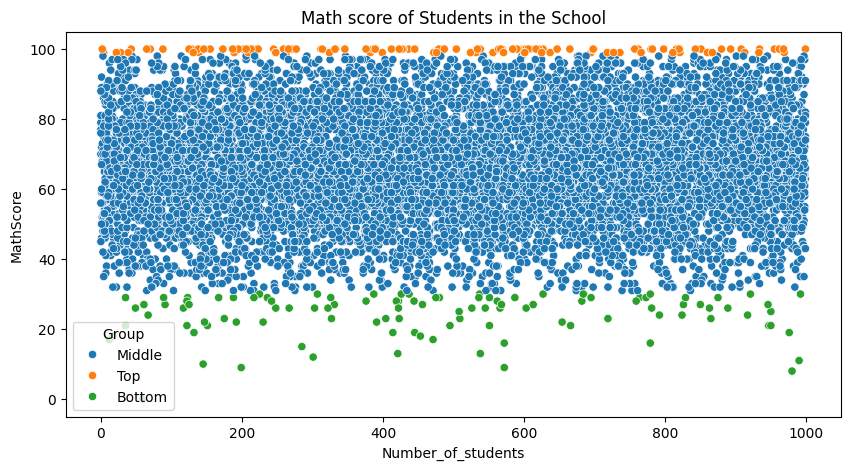

In [45]:
plot_data = (df
             .sample(10000)
             .assign(Group = lambda d: np.select(
                 [d['MathScore'] >= q_99, d['MathScore'] <= q_01],
                 ['Top', 'Bottom'], 'Middle'))
             )

plt.figure(figsize=(10,5))
sns.scatterplot(y="MathScore", x="Number_of_students", hue="Group",data=plot_data)
plt.title("Math score of Students in the School");

In [41]:
df.rename(columns={'Unnamed: 0': 'Number_of_students'}, inplace=True)
df.columns

Index(['Number_of_students', 'Gender', 'EthnicGroup', 'ParentEduc',
       'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport',
       'IsFirstChild', 'NrSiblings', 'TransportMeans', 'WklyStudyHours',
       'MathScore', 'ReadingScore', 'WritingScore'],
      dtype='object')

In [49]:
true_std = df['MathScore'].std()
true_mean = df['MathScore'].mean()
n = 1000

np.float64(66.5584021409223)